## Delay Ranking (based on Airport arrival ATFM delays*)

*The duration between the last take-off time requested by the aircraft operator and the take-off slot allocated by the Network Manager

In [34]:
# Imports & connections
import pandas as pd
import os
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()
DB_URL = os.getenv('DATABASE_URL')
engine = create_engine(DB_URL)

#### 1. Airport-Ranking

In [35]:
# SQL query

query = """
SELECT
    apt_icao,
    apt_name,
    state_name,
    SUM(flt_arr_1) AS total_arrivals,
    SUM(dly_apt_arr_1) AS total_delay_min,
    ROUND(SUM(dly_apt_arr_1) / NULLIF(SUM(flt_arr_1), 0), 2) AS avg_delay_per_arrival,
    ROUND(SUM(flt_arr_1_dly)::NUMERIC / NULLIF(SUM(flt_arr_1), 0) * 100, 2) AS pct_delayed
FROM fact_airport_delay
GROUP BY apt_icao, apt_name, state_name
HAVING
    SUM(dly_apt_arr_1) IS NOT NULL AND
    SUM(flt_arr_1) > 50000
ORDER BY avg_delay_per_arrival DESC
LIMIT 20;
"""
df_apt = pd.read_sql(query, engine)

In [36]:
# Analysis & Visualisation
df_apt.head(20)

,apt_icao,apt_name,state_name,total_arrivals,total_delay_min,avg_delay_per_arrival,pct_delayed
0,LGSA,Khania/Souda,Greece,127099,631711.0,4.97,18.01
1,LGMK,Mikonos,Greece,78092,387790.0,4.97,16.51
2,LGZA,Zakinthos,Greece,60968,266584.0,4.37,16.47
3,LPPT,Lisbon,Portugal,985422,3040183.0,3.09,16.53
4,EHAM,Amsterdam/ Schiphol,Netherlands,2247874,6771605.0,3.01,16.49
5,LTFJ,Istanbul/ Sabiha GÃ¶kÃ§en,Turkey,695186,2033864.0,2.93,12.03
6,LGIR,Heraklion,Greece,266096,773485.0,2.91,15.19
7,EGKK,London/ Gatwick,United Kingdom,1163210,3232976.0,2.78,11.66
8,LGSR,Santorini,Greece,94496,250389.0,2.65,10.03
9,LGAV,Athens,Greece,1053871,2582365.0,2.45,14.08


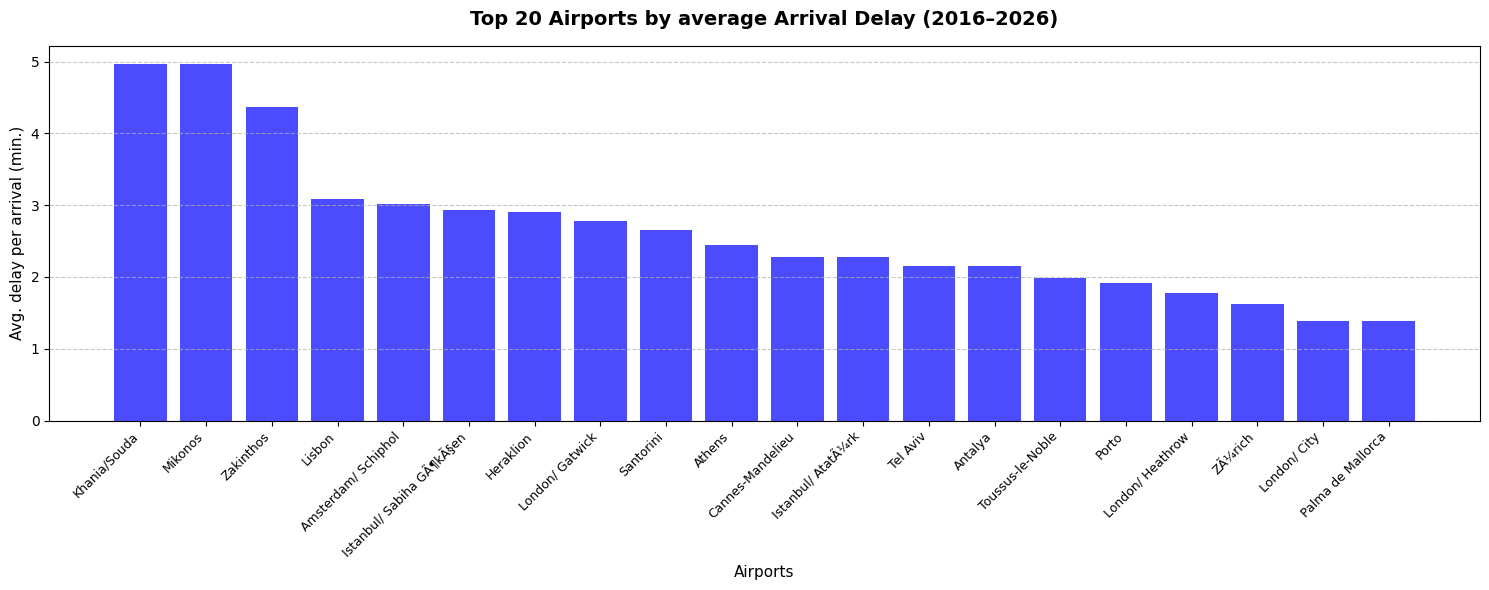

In [40]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.bar(df_apt['apt_name'], df_apt['avg_delay_per_arrival'], color='blue', alpha=0.7, label='Airport arrival delay')

ax.set_title("Top 20 Airports by average Arrival Delay (2016–2026)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Airports", fontsize=11)
ax.set_xticks(range(len(df_apt)))
ax.set_xticklabels(df_apt['apt_name'], rotation=45, fontsize=9, ha='right')
ax.set_ylabel("Avg. delay per arrival (min.)", fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()